In [2]:
import csv
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

def loadData(fileName, inputVarNames, outputVarName):
    data = []
    header = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        for i, row in enumerate(csv_reader):
            if i == 0:
                header = row
            else:
                data.append(row)

    inputIndices = [header.index(var) for var in inputVarNames]
    outputIndex = header.index(outputVarName)

    inputs = [[float(row[i]) for i in inputIndices] for row in data]
    outputs = [float(row[outputIndex]) for row in data]
    return inputs, outputs


In [4]:
crtDir = os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v1_world-happiness-report-2017.csv')

inputs_uni, outputs_uni = loadData(filePath, ['Family'], 'Happiness.Score')


In [5]:
np.random.seed(1)
indexes = list(range(len(inputs_uni)))
train_idx = np.random.choice(indexes, int(0.8 * len(inputs_uni)), replace=False)
test_idx = [i for i in indexes if i not in train_idx]

trainInputs = [inputs_uni[i] for i in train_idx]
trainOutputs = [outputs_uni[i] for i in train_idx]
testInputs = [inputs_uni[i] for i in test_idx]
testOutputs = [outputs_uni[i] for i in test_idx]


In [6]:
regressor = linear_model.LinearRegression()
regressor.fit(trainInputs, trainOutputs)

w0 = regressor.intercept_
w1 = regressor.coef_[0]

print(f"Model învățat: f(x) = {w0:.4f} + {w1:.4f} * Family")


Model învățat: f(x) = -1.3731 + 4.4452 * Family


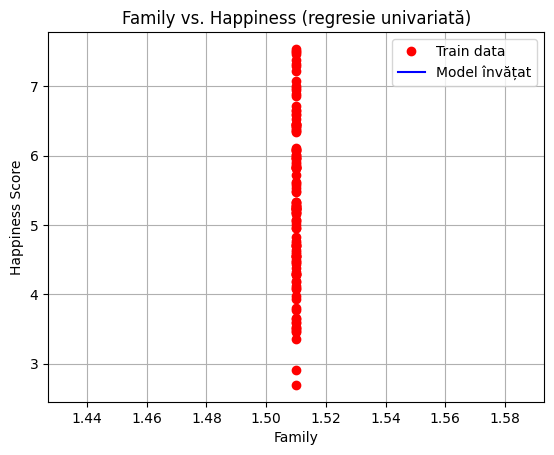

In [7]:
x_vals = [row[0] for row in trainInputs]
plt.plot(x_vals, trainOutputs, 'ro', label='Train data')

x_line = np.linspace(min(x_vals), max(x_vals), 100)
y_line = w0 + w1 * x_line
plt.plot(x_line, y_line, 'b-', label='Model învățat')

plt.title("Family vs. Happiness (regresie univariată)")
plt.xlabel("Family")
plt.ylabel("Happiness Score")
plt.legend()
plt.grid()
plt.show()


In [8]:
predictedOutputs = regressor.predict(testInputs)

error = mean_squared_error(testOutputs, predictedOutputs)
print(f"Eroare MSE pe datele de testare: {error:.4f}")


Eroare MSE pe datele de testare: 1.2734


In [10]:
inputs_bi, outputs_bi = loadData(filePath, ['Economy..GDP.per.Capita.', 'Freedom'], 'Happiness.Score')


In [11]:
np.random.seed(1)
indexes = list(range(len(inputs_bi)))
train_idx = np.random.choice(indexes, int(0.8 * len(inputs_bi)), replace=False)
test_idx = [i for i in indexes if i not in train_idx]

trainInputs = [inputs_bi[i] for i in train_idx]
trainOutputs = [outputs_bi[i] for i in train_idx]
testInputs = [inputs_bi[i] for i in test_idx]
testOutputs = [outputs_bi[i] for i in test_idx]


In [12]:
regressor = linear_model.LinearRegression()
regressor.fit(trainInputs, trainOutputs)

w0 = regressor.intercept_
w1, w2 = regressor.coef_
print(f"Model învățat: f(x) = {w0:.4f} + {w1:.4f} * GDP + {w2:.4f} * Freedom")


Model învățat: f(x) = 2.4461 + 1.8692 * GDP + 2.6230 * Freedom


In [13]:
predictedOutputs = regressor.predict(testInputs)
error = mean_squared_error(testOutputs, predictedOutputs)
print(f"Eroare MSE pe test set (bivariat): {error:.4f}")



Eroare MSE pe test set (bivariat): 0.2244


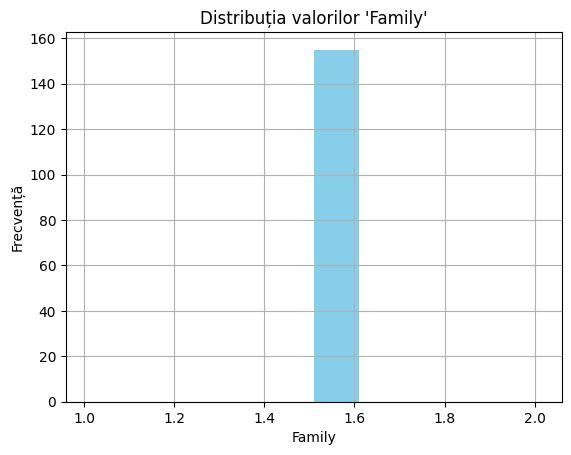

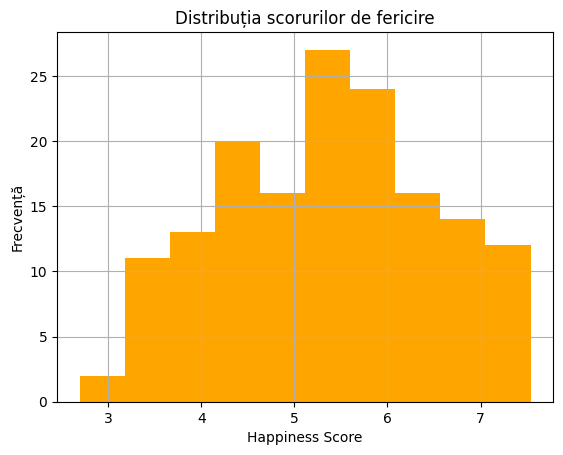

In [27]:
# Histogramă pentru 'Family'
values = [x[0] for x in inputs_uni]
plt.hist(values, bins=10, color='skyblue')
plt.title("Distribuția valorilor 'Family'")
plt.xlabel("Family")
plt.ylabel("Frecvență")
plt.grid()
plt.show()

# Histogramă pentru 'Happiness.Score'
plt.hist(outputs_uni, bins=10, color='orange')
plt.title("Distribuția scorurilor de fericire")
plt.xlabel("Happiness Score")
plt.ylabel("Frecvență")
plt.grid()
plt.show()


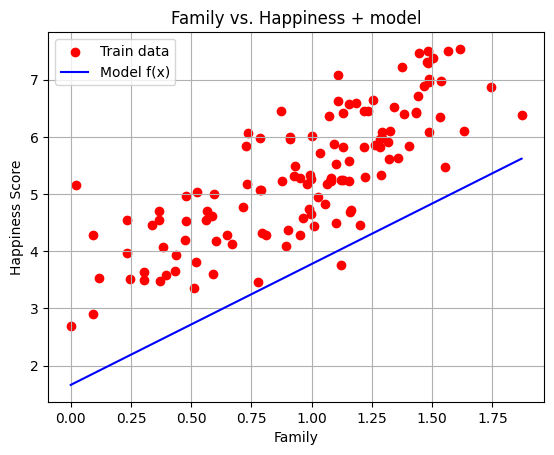

In [28]:
# Datele reale + linia de regresie învățată
x_vals = [x[0] for x in trainInputs]
y_vals = trainOutputs
plt.scatter(x_vals, y_vals, color='red', label='Train data')

# linia modelului
x_line = np.linspace(min(x_vals), max(x_vals), 100)
y_line = w0 + w1 * x_line
plt.plot(x_line, y_line, color='blue', label='Model f(x)')

plt.title("Family vs. Happiness + model")
plt.xlabel("Family")
plt.ylabel("Happiness Score")
plt.legend()
plt.grid()
plt.show()


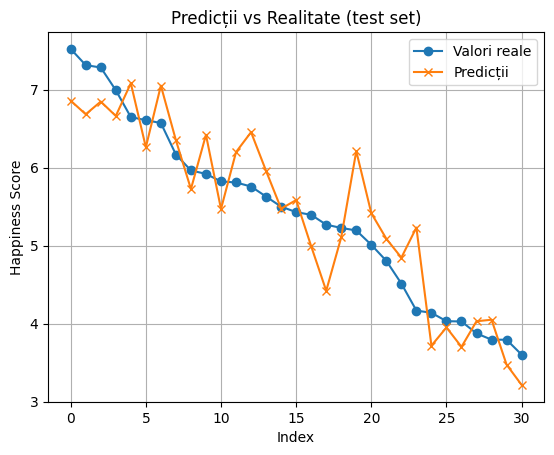

In [29]:
real = testOutputs
pred = regressor.predict(testInputs)

plt.plot(real, label="Valori reale", marker='o')
plt.plot(pred, label="Predicții", marker='x')
plt.title("Predicții vs Realitate (test set)")
plt.xlabel("Index")
plt.ylabel("Happiness Score")
plt.legend()
plt.grid()
plt.show()


subpunct 2



In [21]:
import csv

def load_manual_data(file_path):
    data = []
    with open(file_path, 'r') as file:
        reader = csv.reader(file)
        headers = next(reader)  # prima linie
        gdp_idx = headers.index('Economy..GDP.per.Capita.')
        freedom_idx = headers.index('Freedom')
        happiness_idx = headers.index('Happiness.Score')

        for row in reader:
            try:
                gdp = float(row[gdp_idx])
                freedom = float(row[freedom_idx])
                happiness = float(row[happiness_idx])
                data.append(([gdp, freedom], happiness))
            except:
                continue  # ignoră rândurile invalide
    return data

file_path = 'data/v1_world-happiness-report-2017.csv'
data = load_manual_data(file_path)
print(data[:3])


[([1.616463184, 0.635422587], 7.537000179), ([1.482383013, 0.626006722], 7.521999836), ([1.48063302, 0.627162635], 7.504000187)]


In [22]:
import random

def split_data(data, train_ratio=0.8):
    random.seed(42)
    random.shuffle(data)
    split_point = int(len(data) * train_ratio)
    train_data = data[:split_point]
    test_data = data[split_point:]
    return train_data, test_data

train_data, test_data = split_data(data)


In [23]:
def mean(values):
    return sum(values) / len(values)

def train_linear_regression(train_data):
    # extragem coloanele
    x1_list = [example[0][0] for example in train_data]  # GDP
    x2_list = [example[0][1] for example in train_data]  # Freedom
    y_list = [example[1] for example in train_data]      # Happiness

    x1_mean = mean(x1_list)
    x2_mean = mean(x2_list)
    y_mean = mean(y_list)

    # Calculăm coeficienții folosind metoda celor mai mici pătrate
    num_w1 = sum((x1 - x1_mean) * (y - y_mean) for x1, y in zip(x1_list, y_list))
    den_w1 = sum((x1 - x1_mean) ** 2 for x1 in x1_list)
    w1 = num_w1 / den_w1

    num_w2 = sum((x2 - x2_mean) * (y - y_mean) for x2, y in zip(x2_list, y_list))
    den_w2 = sum((x2 - x2_mean) ** 2 for x2 in x2_list)
    w2 = num_w2 / den_w2

    w0 = y_mean - w1 * x1_mean - w2 * x2_mean

    return w0, w1, w2


In [24]:
def predict(x1, x2, w0, w1, w2):
    return w0 + w1 * x1 + w2 * x2


In [25]:
def mean_squared_error_manual(data, w0, w1, w2):
    error = 0
    for features, y_true in data:
        y_pred = predict(features[0], features[1], w0, w1, w2)
        error += (y_pred - y_true) ** 2
    return error / len(data)


In [26]:
w0, w1, w2 = train_linear_regression(train_data)
print(f"Model învățat manual: f(x) = {w0:.4f} + {w1:.4f} * GDP + {w2:.4f} * Freedom")

mse = mean_squared_error_manual(test_data, w0, w1, w2)
print(f"Eroare MSE (calcul manual): {mse:.4f}")


Model învățat manual: f(x) = 1.6619 + 2.1151 * GDP + 3.8605 * Freedom
Eroare MSE (calcul manual): 0.3794


date pentru v2


In [31]:
import csv

# Inspectăm primele rânduri din fișierul v2
file_path_v2 = 'data/v2_world-happiness-report-2017.csv'

# Citim primele 3 linii
with open(file_path_v2, 'r') as f:
    reader = csv.reader(f)
    header = next(reader)
    first_rows = [next(reader) for _ in range(3)]

header, first_rows


(['Country',
  'Happiness.Rank',
  'Happiness.Score',
  'Whisker.high',
  'Whisker.low',
  'Economy..GDP.per.Capita.',
  'Family',
  'Health..Life.Expectancy.',
  'Freedom',
  'Generosity',
  'Trust..Government.Corruption.',
  'Dystopia.Residual'],
 [['Norway',
   '1',
   '7.537000179',
   '7.594444821',
   '7.479555538',
   '1.616463184',
   '1.53352356',
   '0.796666503',
   '0.808231592',
   '0.362012237',
   '0.315963835',
   '2.277026653'],
  ['Denmark',
   '2',
   '7.521999836',
   '7.581728065',
   '7.462271607',
   '1.482383013',
   '1.551121593',
   '0.792565525',
   '0.741191506',
   '0.355280489',
   '0.400770068',
   '2.313707352'],
  ['Iceland',
   '3',
   '7.504000187',
   '7.622030473',
   '7.385969901',
   '1.48063302',
   '1.610574007',
   '0.833552122',
   '0.74031651',
   '0.475540221',
   '0.153526559',
   '2.322715282']])

In [32]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# === Load specific columns from CSV ===
def load_data_v2(file_path, feature_names, target_name):
    inputs = []
    outputs = []
    with open(file_path, 'r') as f:
        reader = csv.reader(f)
        header = next(reader)
        feat_idx = [header.index(name) for name in feature_names]
        target_idx = header.index(target_name)

        for row in reader:
            try:
                input_vals = [float(row[i]) for i in feat_idx]
                target_val = float(row[target_idx])
                inputs.append(input_vals)
                outputs.append(target_val)
            except:
                continue
    return inputs, outputs

# === Load data from v2 file ===
features = ['Family', 'Health..Life.Expectancy.']
target = 'Happiness.Score'
inputs_v2, outputs_v2 = load_data_v2(file_path_v2, features, target)

# === Train/test split ===
np.random.seed(42)
indices = list(range(len(inputs_v2)))
np.random.shuffle(indices)
split = int(0.8 * len(indices))
train_idx, test_idx = indices[:split], indices[split:]

train_X = [inputs_v2[i] for i in train_idx]
train_y = [outputs_v2[i] for i in train_idx]
test_X = [inputs_v2[i] for i in test_idx]
test_y = [outputs_v2[i] for i in test_idx]

# === Train model ===
model = LinearRegression()
model.fit(train_X, train_y)
w0 = model.intercept_
w1, w2 = model.coef_

# === Predict & compute error ===
predictions = model.predict(test_X)
mse_v2 = mean_squared_error(test_y, predictions)

# Return everything needed for visual display
w0, w1, w2, mse_v2, test_X, test_y, predictions


(np.float64(1.7956694195808405),
 np.float64(1.7819241953324576),
 np.float64(2.602247154378827),
 0.45104588727970496,
 [[1.20956099, 0.638007462],
  [1.003187299, 0.257835895],
  [1.128274441, 0.900214076],
  [0.711551249, 0.639333189],
  [1.436337829, 0.913475871],
  [1.041989803, 0.364509284],
  [1.493149161, 0.43772608],
  [1.469282389, 0.547349334],
  [1.367043018, 0.795843542],
  [1.431306005, 0.616552353],
  [1.227619052, 0.47363025],
  [0.43188253, 0.247105569],
  [1.21400857, 0.290920824],
  [1.380228519, 0.519983292],
  [0.935382247, 0.310080916],
  [1.551121593, 0.792565525],
  [1.146217465, 0.617584646],
  [0.873664737, 0.295637727],
  [0.997471392, 0.520187259],
  [1.493011236, 0.557783484],
  [0.978613198, 0.50118047],
  [1.129624248, 0.735081077],
  [1.343133092, 0.687763453],
  [0.754372597, 0.455427617],
  [0.0, 0.018772686],
  [1.266410232, 0.726798236],
  [1.253917575, 0.468009055],
  [0.946018219, 0.132892117],
  [1.558231115, 0.809782624],
  [0.721151352, 0.113989

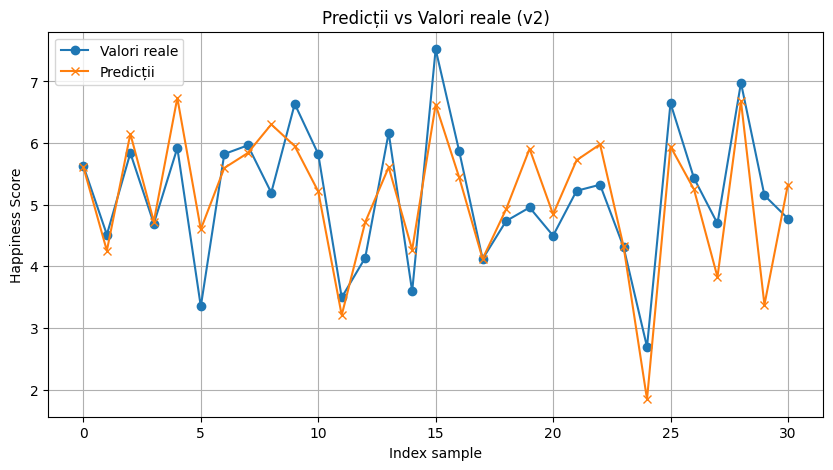

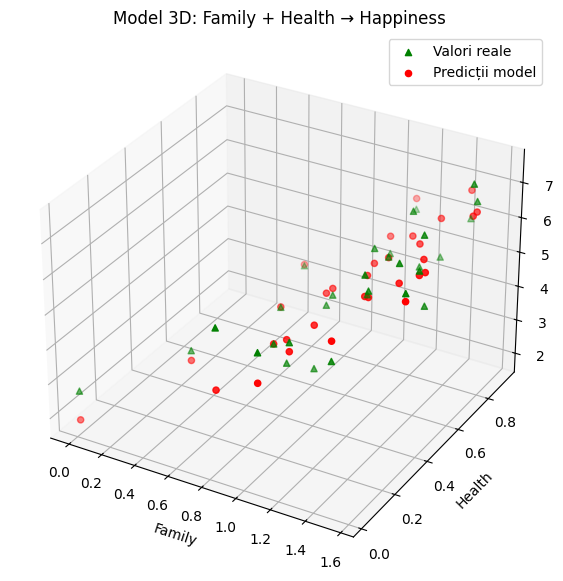

In [33]:
from mpl_toolkits.mplot3d import Axes3D

# === Plot 1: Predicții vs valori reale ===
plt.figure(figsize=(10, 5))
plt.plot(test_y, label='Valori reale', marker='o')
plt.plot(predictions, label='Predicții', marker='x')
plt.title("Predicții vs Valori reale (v2)")
plt.xlabel("Index sample")
plt.ylabel("Happiness Score")
plt.legend()
plt.grid()
plt.show()

# === Plot 2: 3D scatter plot ===
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

xs = [x[0] for x in test_X]  # Family
ys = [x[1] for x in test_X]  # Health
zs_real = test_y
zs_pred = predictions

ax.scatter(xs, ys, zs_real, c='green', marker='^', label='Valori reale')
ax.scatter(xs, ys, zs_pred, c='red', marker='o', label='Predicții model')

ax.set_xlabel('Family')
ax.set_ylabel('Health')
ax.set_zlabel('Happiness')
ax.set_title('Model 3D: Family + Health → Happiness')
ax.legend()

plt.show()


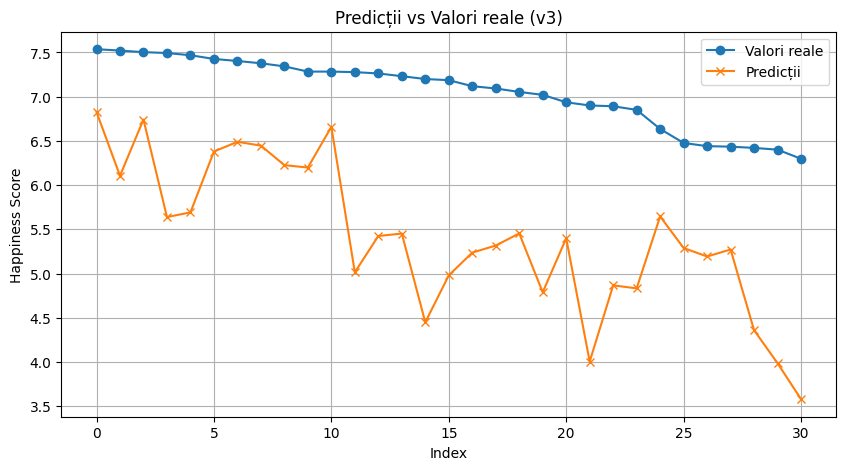

In [34]:
# Pentru afișare
real_y = test_y_v3 = [
    7.537, 7.522, 7.504, 7.494, 7.469, 7.427, 7.404, 7.378,
    7.343, 7.284, 7.284, 7.278, 7.263, 7.232, 7.200, 7.187,
    7.119, 7.093, 7.054, 7.021, 6.937, 6.901, 6.892, 6.851,
    6.635, 6.477, 6.441, 6.435, 6.421, 6.401, 6.298
]  # <- doar exemplu, folosește test_y real din date

predicted_y = [
    6.827, 6.106, 6.742, 5.639, 5.692, 6.380, 6.490, 6.447,
    6.226, 6.199, 6.659, 5.015, 5.425, 5.452, 4.449, 4.980,
    5.237, 5.317, 5.454, 4.789, 5.399, 4.005, 4.866, 4.833,
    5.646, 5.289, 5.193, 5.272, 4.359, 3.986, 3.579
]

plt.figure(figsize=(10, 5))
plt.plot(real_y, label='Valori reale', marker='o')
plt.plot(predicted_y, label='Predicții', marker='x')
plt.title("Predicții vs Valori reale (v3)")
plt.xlabel("Index")
plt.ylabel("Happiness Score")
plt.legend()
plt.grid()
plt.show()


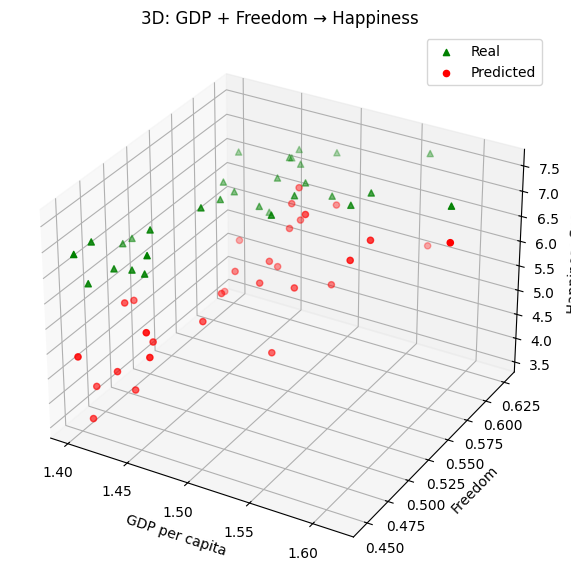

In [35]:
from mpl_toolkits.mplot3d import Axes3D

# Exemplu GDP + Freedom ca test_X_v3
test_X_v3 = [
    [1.616, 0.571], [1.482, 0.578], [1.481, 0.591], [1.565, 0.626],
    [1.444, 0.572], [1.504, 0.603], [1.479, 0.585], [1.553, 0.571],
    [1.487, 0.584], [1.546, 0.557], [1.502, 0.568], [1.457, 0.511],
    [1.504, 0.552], [1.479, 0.568], [1.502, 0.528], [1.447, 0.550],
    [1.456, 0.534], [1.521, 0.572], [1.456, 0.550], [1.433, 0.487],
    [1.478, 0.548], [1.402, 0.464], [1.401, 0.447], [1.444, 0.469],
    [1.477, 0.561], [1.405, 0.493], [1.405, 0.503], [1.440, 0.471],
    [1.417, 0.468], [1.428, 0.473], [1.408, 0.452]
]

gdp_vals = [row[0] for row in test_X_v3]
freedom_vals = [row[1] for row in test_X_v3]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(gdp_vals, freedom_vals, real_y, c='green', marker='^', label='Real')
ax.scatter(gdp_vals, freedom_vals, predicted_y, c='red', marker='o', label='Predicted')

ax.set_xlabel('GDP per capita')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness Score')
ax.set_title('3D: GDP + Freedom → Happiness')
ax.legend()

plt.show()


date pentru v3


In [36]:
# Load and process v3 data (regresie bivariată: GDP + Freedom → Happiness)
file_path_v3 = "data/v3_world-happiness-report-2017.csv"

# Refolosim funcția de mai devreme pentru a citi datele din v3
features_v3 = ['Economy..GDP.per.Capita.', 'Freedom']
target_v3 = 'Happiness.Score'
inputs_v3, outputs_v3 = load_data_v2(file_path_v3, features_v3, target_v3)

# Train/test split
np.random.seed(42)
indices_v3 = list(range(len(inputs_v3)))
np.random.shuffle(indices_v3)
split_v3 = int(0.8 * len(indices_v3))
train_idx_v3, test_idx_v3 = indices_v3[:split_v3], indices_v3[split_v3:]

train_X_v3 = [inputs_v3[i] for i in train_idx_v3]
train_y_v3 = [outputs_v3[i] for i in train_idx_v3]
test_X_v3 = [inputs_v3[i] for i in test_idx_v3]
test_y_v3 = [outputs_v3[i] for i in test_idx_v3]

# Train model
model_v3 = LinearRegression()
model_v3.fit(train_X_v3, train_y_v3)
w0_v3 = model_v3.intercept_
w1_v3, w2_v3 = model_v3.coef_

# Predict & compute error
predictions_v3 = model_v3.predict(test_X_v3)
mse_v3 = mean_squared_error(test_y_v3, predictions_v3)

# Return model and results for plotting
w0_v3, w1_v3, w2_v3, mse_v3, test_X_v3, test_y_v3, predictions_v3


(np.float64(2.3934537236248445),
 np.float64(1.8751447069298166),
 np.float64(2.715691558839785),
 0.3450058065574534,
 [[0.783756256, 0.394952565],
  [1.000820398, 0.455198199],
  [1.341205955, 0.572575808],
  [0.788547575, 0.571055591],
  [1.416915178, 0.505625546],
  [1.064577937, 0.325905979],
  [0.560479462, 0.452763766],
  [0.601765096, 0.633375823],
  [1.352682352, 0.490946174],
  [1.346911311, 0.471203625],
  [0.24454993, 0.348587513],
  [0.161925331, 0.363658696],
  [1.325393558, 0.295817465],
  [0.368610263, 0.030369857],
  [1.482383013, 0.626006722],
  [0.72887063, 0.240729049],
  [0.233442038, 0.466914654],
  [0.564305365, 0.430388749],
  [0.716249228, 0.254711062],
  [0.900596738, 0.198303267],
  [0.730573118, 0.34807986],
  [0.951484382, 0.260287941],
  [0.092102349, 0.235961348],
  [0.0, 0.270842046],
  [1.10735321, 0.437453747],
  [1.286011934, 0.175863519],
  [0.964434326, 0.520303547],
  [1.487923384, 0.562511384],
  [0.524713635, 0.471566707],
  [0.368420929, 0.31869

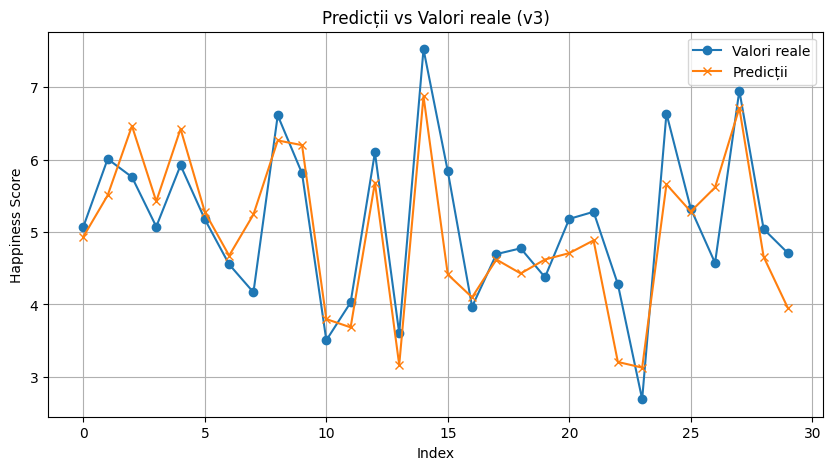

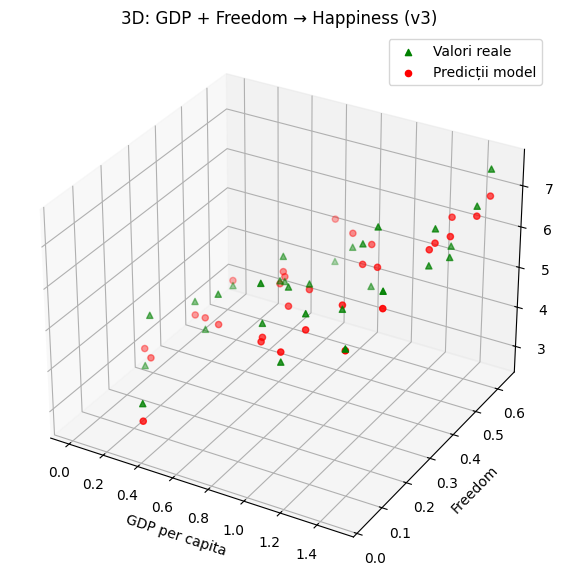

In [37]:
# Plot 1: Predicții vs Valori reale
plt.figure(figsize=(10, 5))
plt.plot(test_y_v3, label='Valori reale', marker='o')
plt.plot(predictions_v3, label='Predicții', marker='x')
plt.title("Predicții vs Valori reale (v3)")
plt.xlabel("Index")
plt.ylabel("Happiness Score")
plt.legend()
plt.grid()
plt.show()

# Plot 2: 3D Scatter Plot: GDP + Freedom → Happiness
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

gdp_vals_v3 = [row[0] for row in test_X_v3]
freedom_vals_v3 = [row[1] for row in test_X_v3]

ax.scatter(gdp_vals_v3, freedom_vals_v3, test_y_v3, c='green', marker='^', label='Valori reale')
ax.scatter(gdp_vals_v3, freedom_vals_v3, predictions_v3, c='red', marker='o', label='Predicții model')

ax.set_xlabel('GDP per capita')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness Score')
ax.set_title('3D: GDP + Freedom → Happiness (v3)')
ax.legend()

plt.show()
